# 02. Feature Improvements — Breaking Through R² = 0.75

This notebook implements **5 cumulative experiments** to improve NSW1 electricity price forecasting:

| Experiment | Added on top of… | Key Improvement |
|---|---|---|
| **1 (Baseline)** | — | Cap + 6 lags + raw time features |
| **2** | Exp 1 | Cyclical sin/cos time encoding |
| **3** | Exp 2 | KNN + Random Forest + tuned XGBoost |
| **4** | Exp 2 | Log-transformed target |
| **5** | Exp 2 | Wavelet decomposition (3-level db4) |

In [1]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Add parent directory to path for src imports
sys.path.append(os.path.abspath('..'))
from src.data_processing import calculate_caps, apply_capping

# Try importing pywt for Experiment 5
try:
    import pywt
    HAS_PYWT = True
    print('PyWavelets available ✓')
except ImportError:
    HAS_PYWT = False
    print('PyWavelets NOT installed. Install with: pip install PyWavelets')
    print('Experiment 5 (Wavelet) will be skipped.')

print('All imports loaded.')

/Users/yaisanadone/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


PyWavelets available ✓
All imports loaded.


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
REGION = 'NSW1'
DATA_PATH = '../data/prices_wide_clean.parquet'
START_DATE = '2021-10-01'
N_LAGS = 6
PREDICTION_HORIZON = 6  # 6 × 5-min = 30-min ahead
TRAIN_RATIO = 0.8

print(f'Region:     {REGION}')
print(f'Lags:       {N_LAGS}')
print(f'Horizon:    {PREDICTION_HORIZON} intervals (={PREDICTION_HORIZON*5} min)')
print(f'Split:      {TRAIN_RATIO:.0%} / {1-TRAIN_RATIO:.0%}')

Region:     NSW1
Lags:       6
Horizon:    6 intervals (=30 min)
Split:      80% / 20%


In [3]:
# =============================================================================
# DATA LOADING (from Silver parquet)
# =============================================================================
try:
    df_wide = pd.read_parquet(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError("Run '00_data_preprocess.ipynb' first.")

# Ensure datetime index
if not isinstance(df_wide.index, pd.DatetimeIndex):
    df_wide.index = pd.to_datetime(df_wide.index)

df_wide = df_wide[df_wide.index >= START_DATE]

# Keep only NSW1 for this notebook
df_nsw = df_wide[[REGION]].copy()
df_nsw = df_nsw.reset_index()
df_nsw = df_nsw.rename(columns={'index': 'date_time'}) if 'date_time' not in df_nsw.columns else df_nsw

print(f'Loaded: {len(df_nsw):,} rows, range: {df_nsw["date_time"].min()} → {df_nsw["date_time"].max()}')
df_nsw.head()

Loaded: 348,383 rows, range: 2021-10-01 00:00:00 → 2025-01-22 15:50:00


,date_time,NSW1
0,2021-10-01 00:00:00,48.10
1,2021-10-01 00:05:00,43.64
2,2021-10-01 00:10:00,54.74
3,2021-10-01 00:15:00,62.43
4,2021-10-01 00:20:00,55.01


In [4]:
# =============================================================================
# CAPPING (IQR method, same as baseline)
# =============================================================================
min_caps, max_caps = calculate_caps(df_nsw, regions=[REGION])
df_capped = apply_capping(df_nsw, min_caps, max_caps, regions=[REGION])

print(f'\nCap range: ${min_caps[REGION]:.2f} to ${max_caps[REGION]:.2f}')
print(f'Values capped: {(df_nsw[REGION] != df_capped[REGION]).sum():,}')


Calculating Caps:
  NSW1: Min=-65.62, Max=264.98

Cap range: $-65.62 to $264.98
Values capped: 37,335


---
## Helper Functions

Shared functions used across experiments to keep the code DRY.

In [5]:
# =============================================================================
# HELPER: Evaluate all models on a given feature set
# =============================================================================

def compute_smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom > 1e-6
    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def evaluate_models(X_train, X_test, y_train, y_test, models, experiment_name):
    """Train and evaluate a dictionary of models. Returns results DataFrame."""
    results = []

    print(f'\n{"="*70}')
    print(f'  {experiment_name}')
    print(f'  Features: {X_train.shape[1]} | Train: {len(X_train):,} | Test: {len(X_test):,}')
    print(f'{"="*70}')

    for name, model in models.items():
        print(f'  Training {name}...', end=' ')
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        r2   = r2_score(y_test, preds)
        mae  = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        smape = compute_smape(y_test.values if hasattr(y_test, 'values') else y_test, preds)

        results.append({
            'Model': name, 'R2': round(r2, 4),
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'sMAPE': round(smape, 2)
        })
        print(f'R²={r2:.4f} | MAE=${mae:.2f} | RMSE=${rmse:.2f} | sMAPE={smape:.2f}%')

    df_res = pd.DataFrame(results).sort_values('R2', ascending=False)
    print(f'\n  → Best: {df_res.iloc[0]["Model"]} with R²={df_res.iloc[0]["R2"]}')
    return df_res


def time_split(X, y, ratio=0.8):
    """Simple time-based train/test split."""
    n = int(len(X) * ratio)
    return X.iloc[:n], X.iloc[n:], y.iloc[:n], y.iloc[n:]

print('Helper functions defined ✓')

Helper functions defined ✓


---
## Experiment 1: Baseline (CAP + Lags + Raw Time)

Replicates the original `NSW_copy.ipynb` pipeline exactly for a fair baseline.

In [6]:
# =============================================================================
# EXPERIMENT 1: Baseline — CAP + 6 lags + raw hour/dow/month
# =============================================================================

df_exp1 = df_capped.copy()

# --- Lag features ---
for lag in range(1, N_LAGS + 1):
    df_exp1[f'{REGION}_lag{lag}'] = df_exp1[REGION].shift(lag)

# --- Raw time features ---
df_exp1['hour'] = df_exp1['date_time'].dt.hour
df_exp1['day_of_week'] = df_exp1['date_time'].dt.dayofweek
df_exp1['month'] = df_exp1['date_time'].dt.month

# --- Target: 30 min ahead ---
df_exp1['target'] = df_exp1[REGION].shift(-PREDICTION_HORIZON)

# --- Clean & split ---
df_exp1 = df_exp1.dropna().reset_index(drop=True)

feature_cols_exp1 = [c for c in df_exp1.columns if 'lag' in c] + ['hour', 'day_of_week', 'month']
X1 = df_exp1[feature_cols_exp1]
y1 = df_exp1['target']

X1_train, X1_test, y1_train, y1_test = time_split(X1, y1)

models_baseline = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'XGBoost':           xgb.XGBRegressor(verbosity=0),
}

results_exp1 = evaluate_models(X1_train, X1_test, y1_train, y1_test,
                               models_baseline, 'EXPERIMENT 1: Baseline (CAP + Lags + Raw Time)')


  EXPERIMENT 1: Baseline (CAP + Lags + Raw Time)
  Features: 9 | Train: 278,696 | Test: 69,675
  Training Linear Regression... R²=0.7190 | MAE=$27.34 | RMSE=$42.12 | sMAPE=39.06%
  Training Ridge... R²=0.7190 | MAE=$27.34 | RMSE=$42.12 | sMAPE=39.06%
  Training Lasso... R²=0.7187 | MAE=$27.35 | RMSE=$42.14 | sMAPE=39.08%
  Training XGBoost... R²=0.7522 | MAE=$25.64 | RMSE=$39.55 | sMAPE=38.29%

  → Best: XGBoost with R²=0.7522


---
## Experiment 2: Cyclical Time Encoding

**Problem:** Raw `hour=23` and `hour=0` are 23 units apart — but only 1 hour apart in reality.  
**Fix:** Map time features onto a unit circle with sin/cos so that nearby times have similar values.

$$
\text{hour\_sin} = \sin\!\left(\frac{2\pi \cdot \text{hour}}{24}\right) \qquad
\text{hour\_cos} = \cos\!\left(\frac{2\pi \cdot \text{hour}}{24}\right)
$$


  EXPERIMENT 2: Cyclical Encoding
  Features: 12 | Train: 278,696 | Test: 69,675
  Training Linear Regression... R²=0.7247 | MAE=$27.62 | RMSE=$41.69 | sMAPE=39.76%
  Training Ridge... R²=0.7247 | MAE=$27.62 | RMSE=$41.69 | sMAPE=39.76%
  Training Lasso... R²=0.7234 | MAE=$27.36 | RMSE=$41.78 | sMAPE=39.24%
  Training XGBoost... R²=0.7557 | MAE=$25.55 | RMSE=$39.27 | sMAPE=38.07%

  → Best: XGBoost with R²=0.7557


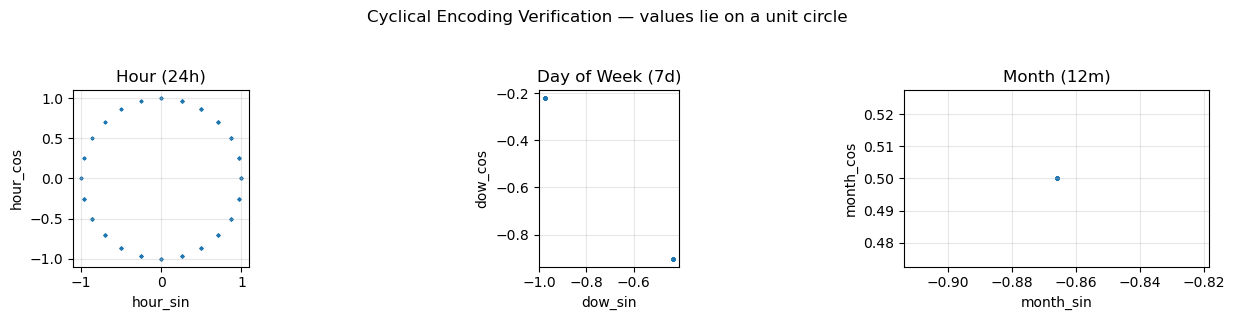

In [7]:
# =============================================================================
# EXPERIMENT 2: Cyclical Encoding — sin/cos for hour, dow, month
# =============================================================================

df_exp2 = df_capped.copy()

# --- Lag features (same as baseline) ---
for lag in range(1, N_LAGS + 1):
    df_exp2[f'{REGION}_lag{lag}'] = df_exp2[REGION].shift(lag)

# --- Extract raw time (intermediate) ---
hour = df_exp2['date_time'].dt.hour
dow  = df_exp2['date_time'].dt.dayofweek
mon  = df_exp2['date_time'].dt.month

# --- CYCLICAL ENCODING ---
df_exp2['hour_sin']  = np.sin(2 * np.pi * hour / 24)
df_exp2['hour_cos']  = np.cos(2 * np.pi * hour / 24)
df_exp2['dow_sin']   = np.sin(2 * np.pi * dow / 7)
df_exp2['dow_cos']   = np.cos(2 * np.pi * dow / 7)
df_exp2['month_sin'] = np.sin(2 * np.pi * mon / 12)
df_exp2['month_cos'] = np.cos(2 * np.pi * mon / 12)

# --- Target ---
df_exp2['target'] = df_exp2[REGION].shift(-PREDICTION_HORIZON)
df_exp2 = df_exp2.dropna().reset_index(drop=True)

feature_cols_exp2 = (
    [c for c in df_exp2.columns if 'lag' in c]
    + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
)
X2 = df_exp2[feature_cols_exp2]
y2 = df_exp2['target']

X2_train, X2_test, y2_train, y2_test = time_split(X2, y2)

models_exp2 = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'XGBoost':           xgb.XGBRegressor(verbosity=0),
}

results_exp2 = evaluate_models(X2_train, X2_test, y2_train, y2_test,
                               models_exp2, 'EXPERIMENT 2: Cyclical Encoding')

# Quick sanity check — visualize the encoding
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (s, c, label) in zip(axes, [
    ('hour_sin', 'hour_cos', 'Hour (24h)'),
    ('dow_sin', 'dow_cos', 'Day of Week (7d)'),
    ('month_sin', 'month_cos', 'Month (12m)')
]):
    sample = df_exp2.iloc[:500]
    ax.scatter(sample[s], sample[c], s=2, alpha=0.5)
    ax.set_xlabel(s); ax.set_ylabel(c)
    ax.set_title(label); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.suptitle('Cyclical Encoding Verification — values lie on a unit circle', y=1.05)
plt.tight_layout()
plt.show()

---
## Experiment 3: Non-Linear Ensemble Models

Using the **Experiment 2 features** (cyclical encoding), we now add stronger non-linear models:
- **K-Nearest Neighbors** (distance-weighted)
- **Random Forest** (bagged trees)
- **Tuned XGBoost** (higher n_estimators, regularization)

In [8]:
# =============================================================================
# EXPERIMENT 3: Non-Linear Ensemble Models (on Exp 2 features)
# =============================================================================

# Reuse X2/y2 from Experiment 2 (cyclical features are already there)
models_exp3 = {
    'XGBoost (tuned)': xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        verbosity=0, n_jobs=-1
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15,
        min_samples_leaf=5, n_jobs=-1, random_state=42
    ),
    'KNN (k=10)': KNeighborsRegressor(
        n_neighbors=10, weights='distance',
        algorithm='ball_tree', n_jobs=-1
    ),
}

print('⚠  KNN on 280K+ rows can be slow (~2–5 min). Please wait...')

results_exp3 = evaluate_models(X2_train, X2_test, y2_train, y2_test,
                               models_exp3, 'EXPERIMENT 3: Ensemble Models + Cyclical')

⚠  KNN on 280K+ rows can be slow (~2–5 min). Please wait...

  EXPERIMENT 3: Ensemble Models + Cyclical
  Features: 12 | Train: 278,696 | Test: 69,675
  Training XGBoost (tuned)... R²=0.7588 | MAE=$25.31 | RMSE=$39.02 | sMAPE=37.80%
  Training Random Forest... R²=0.7528 | MAE=$25.58 | RMSE=$39.50 | sMAPE=37.63%
  Training KNN (k=10)... R²=0.7056 | MAE=$28.21 | RMSE=$43.11 | sMAPE=40.15%

  → Best: XGBoost (tuned) with R²=0.7588


---
## Experiment 4: Log-Transformed Target

**Problem:** The price distribution is heavily right-skewed even after capping at $300. Spikes compress the model's ability to learn the normal $50–$150 range accurately.

**Fix:** Apply `log1p(price + shift)` to compress the scale, train on log-space, then inverse-transform predictions.

> **Important:** All final metrics are computed on the **original $/MWh scale** for fair comparison.

In [9]:
# =============================================================================
# EXPERIMENT 4: Log Transform (on Exp 2 cyclical features)
# =============================================================================

df_exp4 = df_capped.copy()

# --- Shift prices to be strictly positive before log ---
SHIFT_VAL = abs(df_exp4[REGION].min()) + 1  # ensure all values > 0
df_exp4[f'{REGION}_log'] = np.log1p(df_exp4[REGION] + SHIFT_VAL)

print(f'Shift value: {SHIFT_VAL:.2f}')
print(f'Log price range: {df_exp4[f"{REGION}_log"].min():.3f} to {df_exp4[f"{REGION}_log"].max():.3f}')

# --- Lag features on LOG-space prices ---
for lag in range(1, N_LAGS + 1):
    df_exp4[f'{REGION}_lag{lag}'] = df_exp4[f'{REGION}_log'].shift(lag)

# --- Cyclical time encoding ---
hour = df_exp4['date_time'].dt.hour
dow  = df_exp4['date_time'].dt.dayofweek
mon  = df_exp4['date_time'].dt.month

df_exp4['hour_sin']  = np.sin(2 * np.pi * hour / 24)
df_exp4['hour_cos']  = np.cos(2 * np.pi * hour / 24)
df_exp4['dow_sin']   = np.sin(2 * np.pi * dow / 7)
df_exp4['dow_cos']   = np.cos(2 * np.pi * dow / 7)
df_exp4['month_sin'] = np.sin(2 * np.pi * mon / 12)
df_exp4['month_cos'] = np.cos(2 * np.pi * mon / 12)

# --- Target in LOG space ---
df_exp4['target_log'] = df_exp4[f'{REGION}_log'].shift(-PREDICTION_HORIZON)
# Also keep original target for metrics
df_exp4['target_orig'] = df_exp4[REGION].shift(-PREDICTION_HORIZON)

df_exp4 = df_exp4.dropna().reset_index(drop=True)

feature_cols_exp4 = (
    [c for c in df_exp4.columns if 'lag' in c]
    + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
)
X4 = df_exp4[feature_cols_exp4]
y4_log = df_exp4['target_log']
y4_orig = df_exp4['target_orig']

# --- Split ---
n4 = int(len(X4) * TRAIN_RATIO)
X4_train, X4_test = X4.iloc[:n4], X4.iloc[n4:]
y4_log_train, y4_log_test = y4_log.iloc[:n4], y4_log.iloc[n4:]
y4_orig_test = y4_orig.iloc[n4:]

# --- Train on log-space, evaluate on original scale ---
models_exp4 = {
    'XGBoost (tuned)': xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, verbosity=0, n_jobs=-1
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15,
        min_samples_leaf=5, n_jobs=-1, random_state=42
    ),
}

results_exp4_list = []
print(f'\n{"="*70}')
print(f'  EXPERIMENT 4: Log-Transformed Target + Cyclical Encoding')
print(f'  Features: {X4_train.shape[1]} | Train: {len(X4_train):,} | Test: {len(X4_test):,}')
print(f'{"="*70}')

for name, model in models_exp4.items():
    print(f'  Training {name} (log space)...', end=' ')
    model.fit(X4_train, y4_log_train)
    preds_log = model.predict(X4_test)

    # Inverse transform: expm1 gives back (price + shift), then subtract shift
    preds_orig = np.expm1(preds_log) - SHIFT_VAL

    # Metrics on ORIGINAL scale
    r2   = r2_score(y4_orig_test, preds_orig)
    mae  = mean_absolute_error(y4_orig_test, preds_orig)
    rmse = np.sqrt(mean_squared_error(y4_orig_test, preds_orig))
    smape = compute_smape(y4_orig_test.values, preds_orig)

    results_exp4_list.append({
        'Model': name, 'R2': round(r2, 4),
        'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'sMAPE': round(smape, 2)
    })
    print(f'R²={r2:.4f} | MAE=${mae:.2f} | RMSE=${rmse:.2f} | sMAPE={smape:.2f}%')

results_exp4 = pd.DataFrame(results_exp4_list).sort_values('R2', ascending=False)
print(f'\n  → Best: {results_exp4.iloc[0]["Model"]} with R²={results_exp4.iloc[0]["R2"]}')

Shift value: 66.62
Log price range: 0.693 to 5.807

  EXPERIMENT 4: Log-Transformed Target + Cyclical Encoding
  Features: 12 | Train: 278,696 | Test: 69,675
  Training XGBoost (tuned) (log space)... R²=0.7472 | MAE=$25.47 | RMSE=$39.94 | sMAPE=37.71%
  Training Random Forest (log space)... R²=0.7325 | MAE=$25.89 | RMSE=$41.09 | sMAPE=37.81%

  → Best: XGBoost (tuned) with R²=0.7472


---
## Experiment 5: Wavelet Decomposition

**Concept:** Decompose the price signal into smooth **approximation** (trend) + **detail** (noise) sub-series using a 3-level Discrete Wavelet Transform (DWT). Train a model on each sub-series independently, then sum the predictions.

This approach lets the model focus on predictable patterns without being distracted by the noise.

Wavelet db4 level-3 decomposition
  Sub-series: ['approx', 'detail_1', 'detail_2', 'detail_3']
  Reconstruction error (max abs): 0.00000000


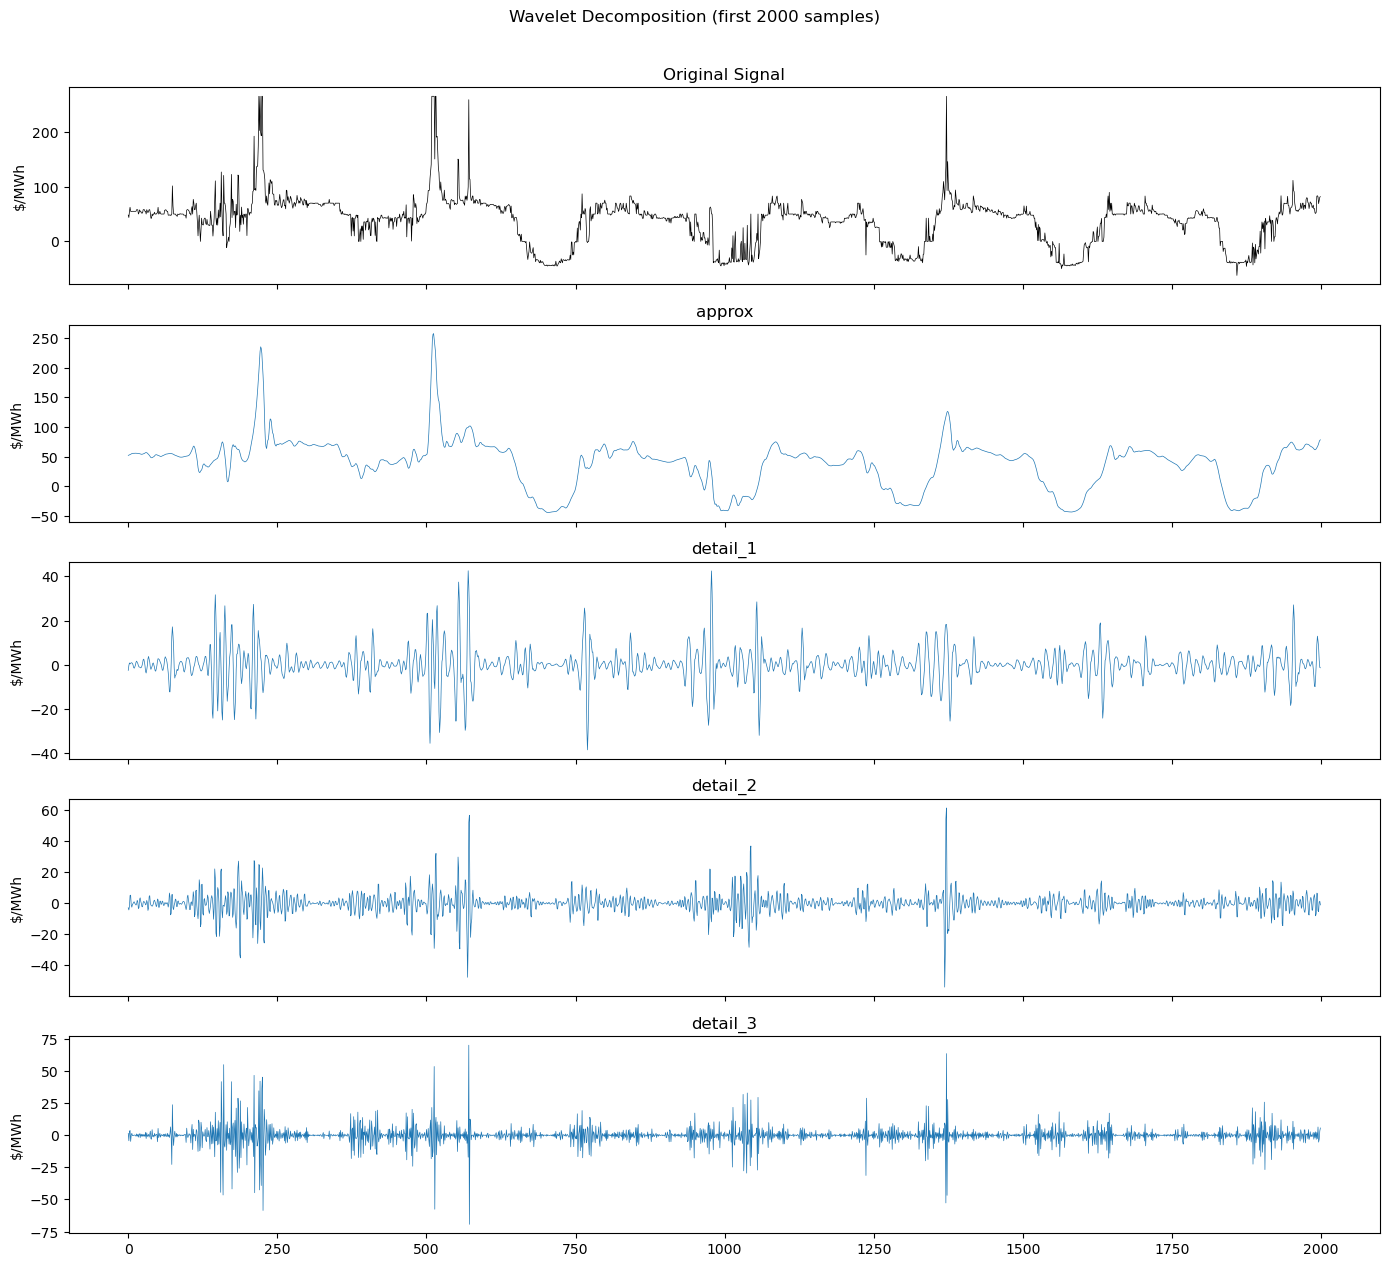

      approx: R²=0.9066 (sub-model)
    detail_1: R²=0.4315 (sub-model)
    detail_2: R²=0.0645 (sub-model)
    detail_3: R²=-0.0095 (sub-model)

  → Combined Wavelet R²=0.8517 | MAE=$19.79 | RMSE=$30.60 | sMAPE=31.91%


In [10]:
# =============================================================================
# EXPERIMENT 5: Wavelet Decomposition + Cyclical Encoding
# =============================================================================

if not HAS_PYWT:
    print('⚠  Skipping Experiment 5 — PyWavelets not installed.')
    results_exp5 = pd.DataFrame(columns=['Model', 'R2', 'MAE', 'RMSE', 'sMAPE'])
else:
    WAVELET = 'db4'
    LEVEL = 3

    prices_capped = df_capped[REGION].values
    dt_index = df_capped['date_time'].values

    # --- Decompose the full signal ---
    coeffs = pywt.wavedec(prices_capped, WAVELET, level=LEVEL)
    # coeffs = [cA3, cD3, cD2, cD1]

    # Reconstruct each sub-series to original length
    sub_series = {}
    for i in range(LEVEL + 1):
        # Zero out all coefficients except the i-th one
        coeffs_i = [np.zeros_like(c) for c in coeffs]
        coeffs_i[i] = coeffs[i]
        reconstructed = pywt.waverec(coeffs_i, WAVELET)
        # waverec can produce +1 sample due to padding; trim
        reconstructed = reconstructed[:len(prices_capped)]
        if i == 0:
            sub_series['approx'] = reconstructed
        else:
            sub_series[f'detail_{i}'] = reconstructed

    # Verify reconstruction
    total_recon = sum(sub_series.values())
    recon_error = np.max(np.abs(prices_capped - total_recon))
    print(f'Wavelet {WAVELET} level-{LEVEL} decomposition')
    print(f'  Sub-series: {list(sub_series.keys())}')
    print(f'  Reconstruction error (max abs): {recon_error:.8f}')

    # Visualize decomposition
    fig, axes = plt.subplots(LEVEL + 2, 1, figsize=(14, 2.5 * (LEVEL + 2)), sharex=True)
    sample_n = 2000
    axes[0].plot(prices_capped[:sample_n], 'k', lw=0.5)
    axes[0].set_title('Original Signal'); axes[0].set_ylabel('$/MWh')
    for idx, (name, series) in enumerate(sub_series.items()):
        axes[idx + 1].plot(series[:sample_n], lw=0.5)
        axes[idx + 1].set_title(f'{name}'); axes[idx + 1].set_ylabel('$/MWh')
    plt.suptitle('Wavelet Decomposition (first 2000 samples)', y=1.01)
    plt.tight_layout()
    plt.show()

    # --- Build features and model for each sub-series, then sum ---
    preds_per_sub = {}
    y_test_per_sub = {}

    for sub_name, sub_vals in sub_series.items():
        df_sub = pd.DataFrame({'date_time': dt_index, 'price': sub_vals})

        # Lags
        for lag in range(1, N_LAGS + 1):
            df_sub[f'lag{lag}'] = df_sub['price'].shift(lag)

        # Cyclical time
        dt_series = pd.to_datetime(df_sub['date_time'])
        df_sub['hour_sin']  = np.sin(2 * np.pi * dt_series.dt.hour / 24)
        df_sub['hour_cos']  = np.cos(2 * np.pi * dt_series.dt.hour / 24)
        df_sub['dow_sin']   = np.sin(2 * np.pi * dt_series.dt.dayofweek / 7)
        df_sub['dow_cos']   = np.cos(2 * np.pi * dt_series.dt.dayofweek / 7)
        df_sub['month_sin'] = np.sin(2 * np.pi * dt_series.dt.month / 12)
        df_sub['month_cos'] = np.cos(2 * np.pi * dt_series.dt.month / 12)

        # Target
        df_sub['target'] = df_sub['price'].shift(-PREDICTION_HORIZON)
        df_sub = df_sub.dropna().reset_index(drop=True)

        feat_cols = [c for c in df_sub.columns if c not in ['date_time', 'price', 'target']]
        X_sub = df_sub[feat_cols]
        y_sub = df_sub['target']

        n_sub = int(len(X_sub) * TRAIN_RATIO)
        X_sub_train = X_sub.iloc[:n_sub]
        X_sub_test  = X_sub.iloc[n_sub:]
        y_sub_train = y_sub.iloc[:n_sub]
        y_sub_test  = y_sub.iloc[n_sub:]

        # Train XGBoost on this sub-series
        model_sub = xgb.XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, verbosity=0, n_jobs=-1
        )
        model_sub.fit(X_sub_train, y_sub_train)
        pred_sub = model_sub.predict(X_sub_test)

        r2_sub = r2_score(y_sub_test, pred_sub)
        print(f'  {sub_name:>10s}: R²={r2_sub:.4f} (sub-model)')

        preds_per_sub[sub_name] = pred_sub
        y_test_per_sub[sub_name] = y_sub_test.values

    # Sum all sub-series predictions to get final prediction
    # Align lengths (they should be the same since we split at same ratio)
    min_len = min(len(v) for v in preds_per_sub.values())
    final_preds = np.sum([v[:min_len] for v in preds_per_sub.values()], axis=0)
    final_actual = np.sum([v[:min_len] for v in y_test_per_sub.values()], axis=0)

    # Metrics on combined prediction
    r2_wt   = r2_score(final_actual, final_preds)
    mae_wt  = mean_absolute_error(final_actual, final_preds)
    rmse_wt = np.sqrt(mean_squared_error(final_actual, final_preds))
    smape_wt = compute_smape(final_actual, final_preds)

    results_exp5 = pd.DataFrame([{
        'Model': f'Wavelet-XGBoost ({WAVELET} L{LEVEL})',
        'R2': round(r2_wt, 4), 'MAE': round(mae_wt, 2),
        'RMSE': round(rmse_wt, 2), 'sMAPE': round(smape_wt, 2)
    }])

    print(f'\n  → Combined Wavelet R²={r2_wt:.4f} | MAE=${mae_wt:.2f} | RMSE=${rmse_wt:.2f} | sMAPE={smape_wt:.2f}%')

---
## Final Comparison

In [11]:
# =============================================================================
# FINAL COMPARISON — All experiments side by side
# =============================================================================

# Tag each experiment's results
results_exp1['Experiment'] = '1. Baseline'
results_exp2['Experiment'] = '2. Cyclical'
results_exp3['Experiment'] = '3. Ensemble + Cyclical'
results_exp4['Experiment'] = '4. LogTransform + Cyclical'
results_exp5['Experiment'] = '5. Wavelet + Cyclical'

all_results = pd.concat(
    [results_exp1, results_exp2, results_exp3, results_exp4, results_exp5],
    ignore_index=True
)

# Best per experiment
best_per_exp = all_results.loc[all_results.groupby('Experiment')['R2'].idxmax()]
best_per_exp = best_per_exp[['Experiment', 'Model', 'R2', 'MAE', 'RMSE', 'sMAPE']]
best_per_exp = best_per_exp.sort_values('R2', ascending=False)

print('='*75)
print('  FINAL COMPARISON — Best Model per Experiment')
print('='*75)
print(best_per_exp.to_string(index=False))
print('='*75)

# Improvement over baseline
baseline_r2 = best_per_exp[best_per_exp['Experiment'] == '1. Baseline']['R2'].values[0]
overall_best = best_per_exp.iloc[0]
print(f'\n  Baseline R²:     {baseline_r2}')
print(f'  Overall Best:    {overall_best["Experiment"]} / {overall_best["Model"]} → R²={overall_best["R2"]}')
print(f'  R² Improvement:  +{overall_best["R2"] - baseline_r2:.4f}')

  FINAL COMPARISON — Best Model per Experiment
                Experiment                    Model     R2   MAE  RMSE  sMAPE
     5. Wavelet + Cyclical Wavelet-XGBoost (db4 L3) 0.8517 19.79 30.60  31.91
    3. Ensemble + Cyclical          XGBoost (tuned) 0.7588 25.31 39.02  37.80
               2. Cyclical                  XGBoost 0.7557 25.55 39.27  38.07
               1. Baseline                  XGBoost 0.7522 25.64 39.55  38.29
4. LogTransform + Cyclical          XGBoost (tuned) 0.7472 25.47 39.94  37.71

  Baseline R²:     0.7522
  Overall Best:    5. Wavelet + Cyclical / Wavelet-XGBoost (db4 L3) → R²=0.8517
  R² Improvement:  +0.0995


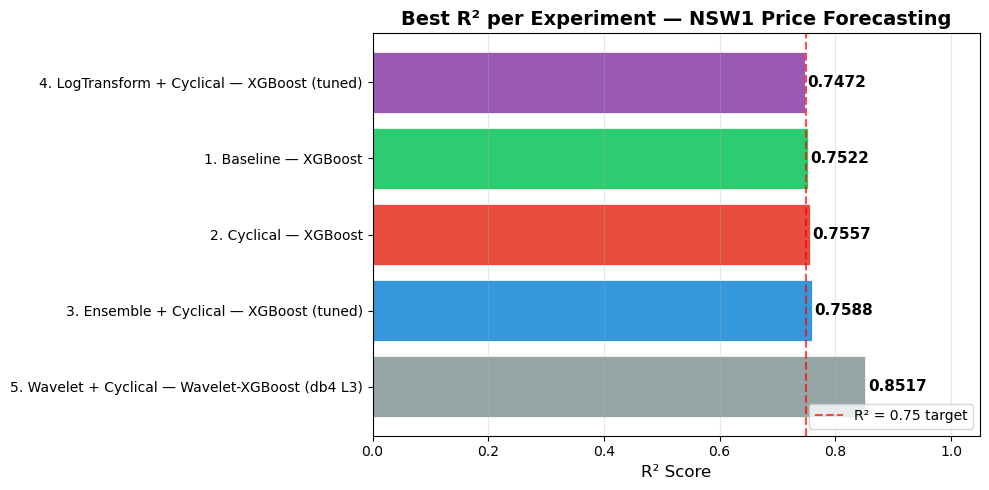

In [12]:
# =============================================================================
# VISUALIZATION — R² comparison bar chart
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.barh(
    best_per_exp['Experiment'] + ' — ' + best_per_exp['Model'],
    best_per_exp['R2'],
    color=colors[:len(best_per_exp)],
    edgecolor='white', linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, best_per_exp['R2']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

# Baseline reference line
ax.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='R² = 0.75 target')

ax.set_xlabel('R² Score', fontsize=12)
ax.set_title('Best R² per Experiment — NSW1 Price Forecasting', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# FULL RESULTS TABLE
# =============================================================================
print('\nFull Results (all models, all experiments):\n')
print(all_results.sort_values(['Experiment', 'R2'], ascending=[True, False]).to_string(index=False))


Full Results (all models, all experiments):

                   Model     R2   MAE  RMSE  sMAPE                 Experiment
                 XGBoost 0.7522 25.64 39.55  38.29                1. Baseline
       Linear Regression 0.7190 27.34 42.12  39.06                1. Baseline
                   Ridge 0.7190 27.34 42.12  39.06                1. Baseline
                   Lasso 0.7187 27.35 42.14  39.08                1. Baseline
                 XGBoost 0.7557 25.55 39.27  38.07                2. Cyclical
       Linear Regression 0.7247 27.62 41.69  39.76                2. Cyclical
                   Ridge 0.7247 27.62 41.69  39.76                2. Cyclical
                   Lasso 0.7234 27.36 41.78  39.24                2. Cyclical
         XGBoost (tuned) 0.7588 25.31 39.02  37.80     3. Ensemble + Cyclical
           Random Forest 0.7528 25.58 39.50  37.63     3. Ensemble + Cyclical
              KNN (k=10) 0.7056 28.21 43.11  40.15     3. Ensemble + Cyclical
         XGBoost (